In [1]:
import sys
sys.path.append('../')
from datetime import datetime
import pytz, os
import numpy as np
import scipy as sp
from tqdm import tqdm
import scqubits as scq
import scqubits.settings as settings
import qutip as qt
from multiprocessing import Pool
from joblib import Parallel, delayed
import pandas as pd
import matplotlib.pyplot as plt
import utils_2Q_gate_zp as ut
# Update scqubits settings
settings.OVERLAP_THRESHOLD = 0.3
max_step, nsteps = 1e-3, 1e4

folder = '../../data/3ncut_one_zeropi/'
evals = scq.read(folder + f'zeropi_0_specdata_truc=1000_3ncut.h5').energy_table
n_theta = scq.read(folder + f'zeropi_0_n_theta_truc=1000_3ncut.h5').matrixelem_table
n_phi = scq.read(folder + f'zeropi_0_n_phi_truc=1000_3ncut.h5').matrixelem_table
evals = evals - evals[0]
# print(np.all(np.imag(n_theta)==0))
# print(np.all(np.real(n_phi)==0))

In [2]:
# drive_phi, drive_theta = False, True
drive_phi, drive_theta = True, False

hspace_theta_78 = [
0,   1,   2,   4,   5,   7,   8,  11,  12,  16,  17,  18,  21,
23,  25,  27,  30,  31,  32,  33,  37,  38,  40,  41,  42,  45,
46,  47,  48,  51,  52,  56,  59,  62,  63,  64,  65,  67,  72,
73,  74,  76,  78,  79,  82,  83,  85,  87,  88,  90,  92,  93,
96,  97,  98, 102, 103, 106, 107, 112, 114, 118, 119, 120, 121,
122, 123, 124, 127, 128, 131, 132, 133, 134, 137, 138, 142, 143
]

hspace_theta_256 = [
0, 1, 2, 4, 5, 7, 8, 11, 12, 16 ,
17, 18, 21, 23, 25, 27, 30, 31, 32, 33 ,
37, 38, 40, 41, 42, 45, 46, 47, 48, 51 ,
52, 56, 59, 62, 63, 64, 65, 67, 72, 73 ,
74, 76, 78, 79, 82, 83, 85, 87, 88, 90 ,

92, 93, 96, 97, 98, 102, 103, 106, 107, 112 ,
114, 118, 119, 120, 121, 122, 123, 124, 127, 128 ,
131, 132, 133, 134, 137, 138, 142, 143, 150, 151 ,
154, 155, 156, 157, 158, 161, 162, 163, 166, 170 ,
171, 174, 175, 176, 177, 179, 180, 186, 187, 188 ,

191, 192, 195, 196, 199, 202, 203, 206, 207, 208 ,
210, 213, 214, 218, 219, 220, 221, 222, 225, 226 ,
230, 231, 232, 236, 237, 238, 242, 243, 246, 247 ,
248, 251, 252, 258, 259, 260, 262, 263, 264, 270 ,
271, 274, 275, 279, 280, 281, 283, 284, 285, 288 ,

289, 290, 294, 296, 297, 298, 299, 300, 301, 302 ,
307, 308, 312, 313, 314, 315, 324, 325, 326, 327 ,
328, 333, 334, 337, 338, 339, 340, 345, 346, 347 ,
348, 350, 351, 354, 355, 358, 359, 364, 365, 366 ,
367, 372, 373, 374, 375, 376, 377, 378, 381, 384 ,

385, 388, 389, 390, 398, 399, 400, 401, 407, 408 ,
410, 411, 413, 414, 418, 419, 420, 425, 426, 427 ,
428, 431, 432, 433, 436, 437, 438, 439, 442, 446 ,
447, 450, 451, 452, 453, 454, 455, 459, 460, 463 ,
464, 467, 468, 472, 473, 474, 475, 476, 486, 488 ,

489, 492, 493, 494, 496, 497 ,
]

hspace_phi_200 = [
0, 9, 2, 33, 10, 19, 25, 37, 31, 23 ,
16, 69, 18, 40, 46, 11, 15, 28, 57, 47 ,
42, 20, 62, 64, 55, 70, 53, 39, 49, 35 ,
51, 73, 56, 83, 24, 77, 76, 86, 66, 43 ,
60, 95, 92, 98, 79, 91, 101, 100, 85, 106 ,

3, 81, 108, 67, 116, 154, 112, 130, 88, 104 ,
121, 133, 96, 110, 113, 158, 146, 143, 123, 132 ,
139, 153, 102, 186, 120, 118, 166, 136, 162, 206 ,
176, 151, 145, 170, 194, 192, 126, 148, 232, 209 ,
141, 196, 220, 128, 253, 137, 159, 164, 173, 188 ,

185, 248, 218, 205, 167, 241, 229, 213, 281, 198 ,
156, 246, 181, 179, 174, 230, 169, 200, 226, 202 ,
265, 305, 190, 264, 259, 255, 223, 216, 250, 306 ,
282, 279, 262, 183, 297, 212, 237, 269, 257, 275 ,
273, 234, 322, 252, 291, 267, 319, 328, 288, 349 ,

227, 294, 336, 242, 239, 208, 315, 286, 320, 333 ,
358, 363, 370, 348, 384, 8, 397, 222, 366, 303 ,
337, 302, 418, 414, 357, 398, 326, 271, 310, 451 ,
438, 352, 346, 277, 245, 474, 283, 445, 313, 407 ,
391, 299, 290, 372, 341, 382, 409, 293, 361, 343 ,
]

hspace_phi_263 = [
0, 2, 3, 4, 8, 9, 10, 11, 15, 16 ,
18, 19, 20, 23, 24, 25, 28, 31, 33, 35 ,
37, 39, 40, 42, 43, 46, 47, 49, 51, 53 ,
55, 56, 57, 60, 62, 64, 66, 67, 69, 70 ,
73, 76, 77, 79, 81, 83, 85, 86, 88, 91 ,

92, 95, 96, 98, 100, 101, 102, 104, 106, 108 ,
110, 112, 113, 116, 118, 120, 121, 123, 126, 128 ,
130, 132, 133, 136, 137, 139, 141, 143, 145, 146 ,
148, 151, 153, 154, 156, 158, 159, 162, 164, 166 ,
167, 169, 170, 173, 174, 176, 179, 181, 183, 185 ,

186, 188, 190, 192, 194, 196, 198, 200, 202, 205 ,
206, 208, 209, 212, 213, 216, 218, 220, 222, 223 ,
226, 227, 229, 230, 232, 234, 237, 239, 241, 242 ,
245, 246, 248, 250, 252, 253, 255, 257, 259, 262 ,
264, 265, 267, 269, 271, 273, 275, 277, 279, 281 ,

282, 283, 286, 288, 290, 291, 293, 294, 297, 299 ,
302, 303, 305, 306, 308, 310, 313, 315, 317, 319 ,
320, 322, 325, 326, 328, 330, 332, 333, 336, 337 ,
340, 341, 343, 346, 348, 349, 350, 352, 354, 357 ,
358, 361, 363, 364, 366, 368, 370, 372, 374, 376 ,

378, 379, 382, 384, 386, 388, 390, 391, 393, 395 ,
397, 398, 400, 403, 405, 407, 409, 411, 414, 415 ,
417, 418, 420, 422, 424, 426, 428, 430, 432, 435 ,
436, 438, 441, 442, 444, 445, 447, 449, 451, 453 ,
455, 457, 460, 461, 464, 465, 468, 469, 471, 472 ,

474, 476, 478, 480, 482, 484, 487, 488, 491, 492 ,
494, 497, 498 ,
]

hspace = hspace_theta_256 if drive_theta else hspace_phi_263
state_mid = 7 if drive_theta else 9
idx_2 = hspace.index(2)
idx_mid = hspace.index(state_mid)
hspace_len = len(hspace)

t1_other = 50 # μs
gamma_decay_other =  1 / 1e3 / t1_other
gamma_dephase_other = 1 / 1e3 / t1_other

In [3]:
# q0 = np.load("../data/data_flux_derivative_q0_eval_300_cpu_100.npz")
# q1 = np.load("../data/data_flux_derivative_q1_eval_300_cpu_100.npz")
q0 = np.load("../data/data_flux_derivative_q0_eval_500.npz")
q1 = np.load("../data/data_flux_derivative_q1_eval_500.npz")
flux = q0["param_vals"]
energy_table = q0["energy_table"]
# print(f"np.shape(flux)={np.shape(flux)}")
# print(f"np.shape(energy_table)={np.shape(energy_table)}")
# print(f"EJ={q0['EJ']}")
# print(f"evals_count={q0['evals_count']}")
# print(f"num_cpus={q0['num_cpus']}")
# print(f"energy_table={energy_table[:5,:5]}")
# print(q0['gamma_phi_1us_02'][:10])
# print(q1['gamma_phi_1us_02'][:10])
print(list(q0.keys()))
print(list(q1.keys()))
# print(f"np.shape(q0['gamma_1_1us_48'])={np.shape(q0['gamma_1_1us_48'])}")
# print(f'len(q0["gamma_phi_1us_02"])={len(q0["gamma_phi_1us_02"])}')

['param_vals', 'energy_table', 'EJ', 'EL', 'ECJ', 'EC', 'dEJ', 'ng', 'flux', 'ncut', 'truncated_dim', 'phi_range', 'phi_cut', 'evals_count', 'num_cpus', 'subtract_ground', 'param_name', 'gamma_phi_1us_02', 'gamma_phi_1us_02_theta_mode', 'gamma_phi_1us_02_phi_mode', 'hspace_theta_256', 'hspace_phi_263']
['param_vals', 'energy_table', 'EJ', 'EL', 'ECJ', 'EC', 'dEJ', 'ng', 'flux', 'ncut', 'truncated_dim', 'phi_range', 'phi_cut', 'evals_count', 'num_cpus', 'subtract_ground', 'param_name', 'gamma_phi_1us_02', 'gamma_phi_1us_02_theta_mode', 'gamma_phi_1us_02_phi_mode', 'hspace_theta_256', 'hspace_phi_263']


In [14]:
gamma_phi_1us_02 = [q0['gamma_phi_1us_02'][i] for i in hspace_theta_256]

In [4]:
q0['hspace_theta_256']

array([  0,   1,   2,   4,   5,   7,   8,  11,  12,  16,  17,  18,  21,
        23,  25,  27,  30,  31,  32,  33,  37,  38,  40,  41,  42,  45,
        46,  47,  48,  51,  52,  56,  59,  62,  63,  64,  65,  67,  72,
        73,  74,  76,  78,  79,  82,  83,  85,  87,  88,  90,  92,  93,
        96,  97,  98, 102, 103, 106, 107, 112, 114, 118, 119, 120, 121,
       122, 123, 124, 127, 128, 131, 132, 133, 134, 137, 138, 142, 143,
       150, 151, 154, 155, 156, 157, 158, 161, 162, 163, 166, 170, 171,
       174, 175, 176, 177, 179, 180, 186, 187, 188, 191, 192, 195, 196,
       199, 202, 203, 206, 207, 208, 210, 213, 214, 218, 219, 220, 221,
       222, 225, 226, 230, 231, 232, 236, 237, 238, 242, 243, 246, 247,
       248, 251, 252, 258, 259, 260, 262, 263, 264, 270, 271, 274, 275,
       279, 280, 281, 283, 284, 285, 288, 289, 290, 294, 296, 297, 298,
       299, 300, 301, 302, 307, 308, 312, 313, 314, 315, 324, 325, 326,
       327, 328, 333, 334, 337, 338, 339, 340, 345, 346, 347, 34

In [6]:
q0['gamma_phi_1us_02'][:5]

array([-0.00000000e+00,  1.78113529e-07,  1.00000000e-03, -9.99662044e-04,
       -1.13285311e-07])

In [5]:
q0['gamma_phi_1us_02']

array([-0.00000000e+00,  1.78113529e-07,  1.00000000e-03, -9.99662044e-04,
       -1.13285311e-07,  2.90423785e-04, -2.89888970e-04,  2.75843051e-07,
        5.73620780e-05, -5.28250834e-05,  1.07610812e-06, -3.13143559e-06,
        1.16420199e-04, -1.11761354e-04, -7.01409606e-07,  3.83267420e-06,
        2.40679288e-05, -9.63049071e-08,  3.18986849e-05, -5.05719598e-05,
       -3.90435820e-06,  1.69806771e-05,  3.22887471e-07,  1.52504478e-03,
       -1.45007832e-03, -7.00243426e-05, -1.42846042e-05,  2.26002933e-05,
       -9.28829857e-08,  1.63338955e-04, -1.24451163e-04,  1.52498566e-05,
       -9.52020007e-06,  3.00748956e-06, -3.74222157e-05, -9.73407010e-06,
       -2.74985665e-06,  8.35963479e-05, -3.57774494e-06, -3.30822149e-05,
       -3.79954779e-05,  3.25227629e-06,  1.44710549e-06,  2.13379682e-05,
        1.51882917e-04, -1.01452657e-04, -1.37019043e-05, -1.21285643e-05,
       -4.52091231e-05,  2.70999661e-05,  2.65551358e-05, -2.61787931e-05,
       -2.23237507e-05,  

### $T_\phi$ wrong derivative

In [ ]:
folder = '../../data/3ncut_one_zeropi/'
df = pd.read_csv(folder+'zeropi_0_eval_500.txt')
derivative = np.array(np.abs(df['eval_flux=0.001'] - df['eval_flux=0']) / 0.001)
derivative = [derivative[i] for i in hspace]

w_ir = 1e-9* 2 * np.pi # 1 Hz
t = 10e3 # 10 us = 10e3 ns
print(' derivative_07=', derivative[idx_mid])
print('derivative_02=', derivative[idx_2])
print('derivative_27=', derivative[idx_mid] - derivative[idx_2] )

# ### Fix A with tphi=50us and 02
A = gamma_dephase_other / (derivative[idx_2] * np.sqrt(2 * np.abs(np.log(w_ir * t))))
print(f'A={A}')
gamma_dephase_50us_02 = A * np.array(derivative) * np.sqrt(2 * np.abs(np.log(w_ir * t)))
# gamma_dephase_50us_02 = np.array([A * derivative[i] * np.sqrt(2 * np.abs(np.log(w_ir * t))) for i in hspace])
print('len(gamma_dephase_50us_02) = ', len(gamma_dephase_50us_02))
# gamma_dephase_50us_02

### Fix A = 1e-6
# A = 1e-6
# gamma_dephase_1e6 = A * np.array(derivative) * np.sqrt(2 * np.abs(np.log(w_ir * t)))
# gamma_dephase_1e6

 derivative_07= 0.10385601443729797
derivative_02= 1.8161089694075372
derivative_27= -1.7122529549702392


In [ ]:
# folder_1 = 'data/data_gamma_'
# folder_2 = 'theta_500.txt' if drive_theta else 'phi_500.txt'
# gamma_new = pd.DataFrame()
# gamma_new['hspace'] = hspace
# # gamma_new['derivative'] = derivative
# gamma_new['tphi_50us_02'] = gamma_dephase_50us_02
# # gamma_new['t1_50us_49'] = gamma_decay_2
# gamma_new.to_csv(folder_1 + folder_2, index=False)


: 

## Debug 1st  vs 2nd derivative

In [ ]:
print('use 1st order dephasing data')
gamma_file = 'data/data_gamma_theta_500.txt' 
gamma_new = pd.read_csv(gamma_file)
gamma_dephase_1st = gamma_new['tphi_50us_02'].to_numpy()
state_idx_1st = gamma_new['hspace'].to_numpy()

In [45]:
print('use 2nd order dephasing data')
gamma_file = '../data/data_flux_derivative_q0_eval_500.npz' 
gamma_new = np.load(gamma_file)
gamma_dephase_label = 'gamma_phi_1us_02_theta_mode' 
gamma_dephase_2nd = np.abs(gamma_new[gamma_dephase_label])
state_idx_label = 'hspace_theta_256' 
state_idx_2nd = gamma_new[state_idx_label]

use 2nd order dephasing data


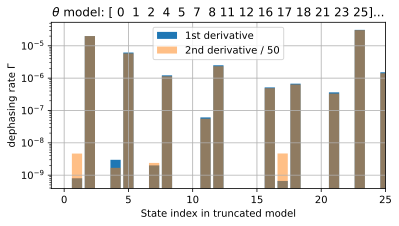

In [48]:
k = 15
plt.figure(figsize=(6,3))
plt.bar(state_idx_2nd[:k], gamma_dephase_1st[:k], label='1st derivative')
plt.bar(state_idx_2nd[:k], gamma_dephase_2nd[:k] / (50), label='2nd derivative / 50', alpha=0.5)
plt.yscale('log')
plt.xlim(-1,25)
plt.grid()
plt.xlabel('State index in truncated model')
plt.ylabel(r'dephasing rate $\Gamma$')
plt.title(fr'$\theta$ model: {state_idx_2nd[:15]}...')
plt.legend()

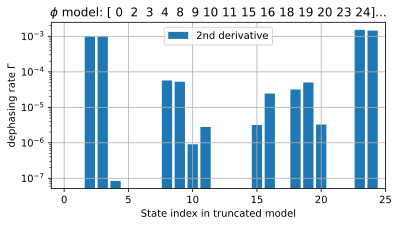

In [39]:
k = 15
x = gamma_new['hspace_phi_263']
y = np.abs(gamma_new['gamma_phi_1us_02_phi_mode'])

plt.figure(figsize=(6,3))
plt.bar(x[:k], y[:k], label='2nd derivative')
plt.yscale('log')
plt.grid()
plt.xlim(-1,25)
plt.xlabel('State index in truncated model')
plt.ylabel(r'dephasing rate $\Gamma$')
plt.title(fr'$\phi$ model: {x[:15]}...')
plt.legend()

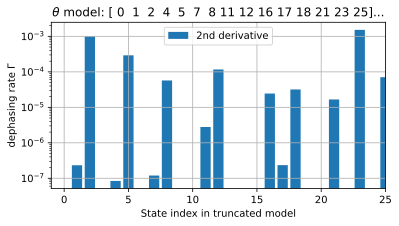

In [41]:
k = 15
x = gamma_new['hspace_theta_256']
y = np.abs(gamma_new['gamma_phi_1us_02_theta_mode'])

plt.figure(figsize=(6,3))
plt.bar(x[:k], y[:k], label='2nd derivative')
plt.yscale('log')
plt.xlim(-1,25)
plt.grid()
plt.xlabel('State index in truncated model')
plt.ylabel(r'dephasing rate $\Gamma$')
plt.title(fr'$\theta$ model: {x[:15]}...')
plt.legend()

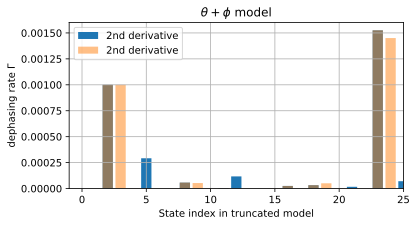

In [56]:
k = 15
plt.figure(figsize=(6,3))

x = gamma_new['hspace_theta_256']
y = np.abs(gamma_new['gamma_phi_1us_02_theta_mode'])
plt.bar(x[:k], y[:k], label='2nd derivative')

x = gamma_new['hspace_phi_263']
y = np.abs(gamma_new['gamma_phi_1us_02_phi_mode'])
plt.bar(x[:k], y[:k], label='2nd derivative', alpha=0.5)

# plt.yscale('log')
plt.xlim(-1,25)
plt.grid()
plt.xlabel('State index in truncated model')
plt.ylabel(r'dephasing rate $\Gamma$')
plt.title(fr'$\theta+\phi$ model')
plt.legend()

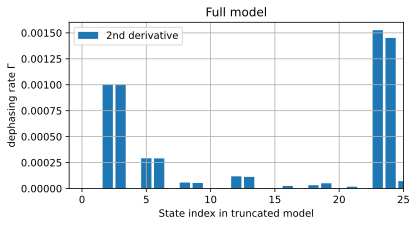

In [55]:
k = 15
y = np.abs(gamma_new['gamma_phi_1us_02'])

plt.figure(figsize=(6,3))
plt.bar( np.arange(len(y)), y, label='2nd derivative')
# plt.yscale('log')
plt.xlim(-1,25)
plt.grid()
plt.xlabel('State index in truncated model')
plt.ylabel(r'dephasing rate $\Gamma$')
plt.title(fr'Full model')
plt.legend()

In [7]:
print([i for i in gamma_new.keys()])

['param_vals', 'energy_table', 'EJ', 'EL', 'ECJ', 'EC', 'dEJ', 'ng', 'flux', 'ncut', 'truncated_dim', 'phi_range', 'phi_cut', 'evals_count', 'num_cpus', 'subtract_ground', 'param_name', 'gamma_phi_1us_02', 'gamma_phi_1us_02_theta_mode', 'gamma_phi_1us_02_phi_mode', 'hspace_theta_256', 'hspace_phi_263']


### Plot gamma

In [ ]:
zp_single = pd.read_csv('data/data_gamma_t1_27_tphi_1e-6_theta.txt')
zp0 = pd.read_csv('../../data/3ncut_two_zeropi/truc1=500/data_gamma_t1_28_tphi_1e-6_qubit0.txt')
zp1 = pd.read_csv('../../data/3ncut_two_zeropi/truc1=500/data_gamma_t1_28_tphi_1e-6_qubit1.txt')

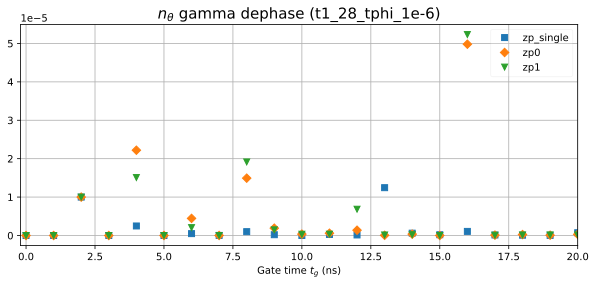

In [ ]:
fig, ax = plt.subplots(figsize=(10,4))
plt.plot(zp_single['dephase_50us'], 's', label=r"zp_single")
plt.plot(zp0['dephase'], 'D', label=r'zp0')
plt.plot(zp1['dephase'], 'v', label=r'zp1')
plt.xlim(-0.2,20)
# plt.ylim(0,)
# plt.yscale('log')
plt.xlabel('Gate time $t_g$ (ns)')
plt.title(r'$n_\theta$ gamma dephase (t1_28_tphi_1e-6)', fontsize=15)
plt.grid()
legend = plt.legend( loc="best")
legend.get_frame().set_alpha(0.2)  # 0.5 makes the legend 50% transparent

### $T_1$

$\gamma_{ll'} = \Gamma | \bra{l} n_\theta \ket{l'} |^2 = 1/ T_1  $ ( $T_1$ is intrawell decay time )

$\gamma_{07} = \Gamma_{07} | \bra{0} n_\theta \ket{7} |^2 = 1 / (2\times 10^{-6})   $

In [ ]:
gamma_decay_0 = []
gamma_decay_2 = []
if drive_theta:
    Gamma_0 = gamma_decay_other / (n_theta[4,7]**2)
    Gamma_2 = gamma_decay_other / (n_theta[2,7]**2)
    for i in hspace:
        gamma_decay_0.append(Gamma_0* n_theta[0, i]**2)
        gamma_decay_2.append(Gamma_2* n_theta[0, i]**2)
else:
    Gamma_0 = gamma_decay_other / (n_phi[0,9]**2)
    Gamma_2 = gamma_decay_other / (n_phi[4,9]**2)
    for i in hspace:
        gamma_decay_0.append(Gamma_0* n_phi[0, i]**2)
        gamma_decay_2.append(Gamma_2* n_phi[0, i]**2)

print('np.imag(gamma_decay_0)=0 -->', np.all(np.imag(gamma_decay_0)==0))
print('np.imag(gamma_decay_2)=0 -->', np.all(np.imag(gamma_decay_2)==0))

if np.all(np.imag(gamma_decay_0)==0) and np.all(np.imag(gamma_decay_2)==0):
    gamma_decay_0 = np.real(gamma_decay_0)
    gamma_decay_2 = np.real(gamma_decay_2)
print('t1_other = %d μs'%t1_other)
print(f'Gamma_0={Gamma_0}, Gamma_2={Gamma_2}')
### Gamma_49 = 0.0029
### Gamma_47 = 5e-6

np.imag(gamma_decay_0)=0 --> True
np.imag(gamma_decay_2)=0 --> True
t1_other = 50 μs
Gamma_0=(-0.008389967311129664-0j), Gamma_2=(-0.002914726072472023-0j)


### Deacy to all states

In [ ]:
if drive_theta:
    Gamma = gamma_decay_other / (n_theta[4,7]**2)
    gamma_decay = Gamma* n_theta**2
else:
    Gamma = gamma_decay_other / (n_phi[4,9]**2)
    gamma_decay = Gamma* n_phi**2

np.imag(gamma_decay_0)=0 --> True
np.imag(gamma_decay_2)=0 --> True
t1_other = 50 μs
Gamma_0=(-0.008389967311129664-0j), Gamma_2=(-0.002914726072472023-0j)


In [ ]:
# hspace_0 = [0, 2]
# for s in hspace_0:
#     for i in range(truc):
#         if np.abs(n_phi[s, i]) > 1e-3 and i not in hspace_0:
#             hspace_0.append(i)
# hspace_0.sort()
# data = hspace_0
# for i in range(0, len(data), 10):  # Step size of 10
#     if i%50==0:
#         print('')
#     print(", ".join(f"{x}" for x in data[i:i + 10]), ',')

# eval_flux = ut.zeropi_eval(flux=0.001, truncation=500)
# df = pd.DataFrame()
# df['eval_flux=0.001'] = eval_flux
# df.to_csv('zeropi_0_eval_500.txt', index=False)